### RAG (Retrieval Augmented Generation) Pipeline
Retrieval-augmented generation (RAG) is a technique that enhances the performance of large language models (LLMs) by integrating them with external knowledge sources. Instead of relying solely on their pre-trained knowledge, RAG enables LLMs to access and incorporate information from a specified set of documents or databases before generating responses. This approach improves the accuracy, relevance, and up-to-date nature of the generated content, especially when dealing with specific domains or proprietary information. 

##### RAG Pipeline includes few steps such as:

1. Data Ingestion : loading of the data from text/pdf/web etc.
2. Data Transformation: creating chunks from document for better vectorization
3. Embeddings and Vector Storage: creating vector embeddings and store in vectordb
4. Query the vectorDB
5. Optional: include llm with Query using chain and retrieval

In [59]:
### Importing basic libs
import os
import mermaid as md # for flow charts
from IPython.display import SVG

### Basic RAG Pipeline

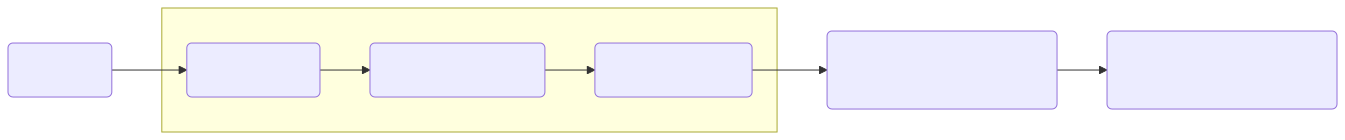

In [60]:
basic_rag_pipeline = """
graph LR
    A( Input Data ) --> B( Data Ingestion );
    
    subgraph Data Processing   
        B -->  C( Data Transformation )
        C -->  D( Data Embeddings )
    end 

    D --> E( Create VectorDB from Embeddings )
    E --> F( Query VectorDB and perform Similarity Search ) 
  
"""

basic_rag_pipeline_fn = "basic_rag_pipeline.svg"
md.Mermaid(basic_rag_pipeline).to_svg(basic_rag_pipeline_fn)
SVG(basic_rag_pipeline_fn)

#### A. Data Ingestion
LangChain support various ways to load the data such as text file, pdf, web etc.

##### Loading data from Text file 

In [2]:
from langchain_community.document_loaders import TextLoader

In [3]:
# constructing file path
textFilePath = os.path.join(os.path.dirname(os.getcwd()), "datafiles" , "rag_wiki_text.txt")

# calling loader and specifying filepath and encoding
text_loader = TextLoader(file_path=textFilePath, encoding="utf-8")

# let's load the data into var
text_documents = text_loader.load()

In [4]:
# let's print the var
text_documents

[Document(metadata={'source': 'd:\\ProjectDesk\\gh-iamatulkumar-ya\\data-science\\langchain_learning\\datafiles\\rag_wiki_text.txt'}, page_content='Retrieval-augmented generation\nRetrieval-augmented generation (RAG) is a technique that enables large language models\n(LLMs) to retrieve and incorporate new information.[1] With RAG, LLMs do not respond to user\nqueries until they refer to a specified set of documents. These documents supplement information\nfrom the LLM\'s pre-existing training data.\n[2] This allows LLMs to use domain-specific and/or updated\ninformation that is not available in the training data.[2][3]\n For example, this helps LLM-based chatbots\naccess internal company data or generate responses based on authoritative sources.\nRAG improves large language models (LLMs) by incorporating information retrieval before\ngenerating responses.[4] Unlike traditional LLMs that rely on static training data, RAG pulls relevant\ntext from databases, uploaded documents, or web so

In [5]:
# let's print the page content
text_documents[0].page_content

'Retrieval-augmented generation\nRetrieval-augmented generation (RAG) is a technique that enables large language models\n(LLMs) to retrieve and incorporate new information.[1] With RAG, LLMs do not respond to user\nqueries until they refer to a specified set of documents. These documents supplement information\nfrom the LLM\'s pre-existing training data.\n[2] This allows LLMs to use domain-specific and/or updated\ninformation that is not available in the training data.[2][3]\n For example, this helps LLM-based chatbots\naccess internal company data or generate responses based on authoritative sources.\nRAG improves large language models (LLMs) by incorporating information retrieval before\ngenerating responses.[4] Unlike traditional LLMs that rely on static training data, RAG pulls relevant\ntext from databases, uploaded documents, or web sources.[1] According to Ars Technica, "RAG is a\nway of improving LLM performance, in essence by blending the LLM process with a web search or\nothe

##### Loading data from web page 

In [6]:
from langchain_community.document_loaders import WebBaseLoader
import bs4

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [7]:
# let's specify the web page link to get the data from.
# next important thing is beautiful soup args that we have to use to parse html
# class_ is the paramter, which is using the classes name which html tag uses for formatting, so we are taking full data where this class is mentioned
web_loader = WebBaseLoader(web_path="https://aws.amazon.com/what-is/retrieval-augmented-generation/", bs_kwargs=dict(parse_only=bs4.SoupStrainer(class_="eb-faq-content")))
html_documents = web_loader.load()

In [8]:
html_documents

[Document(metadata={'source': 'https://aws.amazon.com/what-is/retrieval-augmented-generation/'}, page_content='\n\n\n\nWhat is Retrieval-Augmented Generation?\n\nRetrieval-Augmented Generation (RAG) is the process of optimizing the output of a large language model, so it references an authoritative knowledge base outside of its training data sources before generating a response. Large Language Models (LLMs) are trained on vast volumes of data and use billions of parameters to generate original output for tasks like answering questions, translating languages, and completing sentences. RAG extends the already powerful capabilities of LLMs to specific domains or an organization\'s internal knowledge base, all without the need to retrain the model. It is a cost-effective approach to improving LLM output so it remains relevant, accurate, and useful in various contexts.\n\n\n\n\n\n\n\nWhy is Retrieval-Augmented Generation important?\n\nLLMs are a key artificial intelligence (AI) technology p

In [9]:
html_documents[0].page_content

'\n\n\n\nWhat is Retrieval-Augmented Generation?\n\nRetrieval-Augmented Generation (RAG) is the process of optimizing the output of a large language model, so it references an authoritative knowledge base outside of its training data sources before generating a response. Large Language Models (LLMs) are trained on vast volumes of data and use billions of parameters to generate original output for tasks like answering questions, translating languages, and completing sentences. RAG extends the already powerful capabilities of LLMs to specific domains or an organization\'s internal knowledge base, all without the need to retrain the model. It is a cost-effective approach to improving LLM output so it remains relevant, accurate, and useful in various contexts.\n\n\n\n\n\n\n\nWhy is Retrieval-Augmented Generation important?\n\nLLMs are a key artificial intelligence (AI) technology powering intelligent chatbots and other natural language processing (NLP) applications. The goal is to create b

##### Loading data from pdf file 

In [10]:
from langchain_community.document_loaders import PyPDFLoader # here we have multiple pdf loader, so we would need the corresponding lib to support this
# like in this case pypdf

In [11]:
# constructing file path
pdfFilePath = os.path.join(os.path.dirname(os.getcwd()), "datafiles" , "rag_study.pdf")

# loading the file content, for multiple files we can have "PyPDFDirectoryLoader" 
pdf_loader = PyPDFLoader(file_path=pdfFilePath)

# loading pdf documents from loader
pdf_documents = pdf_loader.load()


In [12]:
pdf_documents[0].page_content

'A Comprehensive Survey of Retrieval-Augmented Generation (RAG): Evolution, CurrentLandscapeandFutureDirections\nShailjaGupta(CarnegieMellonUniversity, USA)RajeshRanjan(CarnegieMellonUniversity, USA)SuryaNarayanSingh(BITSindri, India)\nAbstract\nThis paper presents a comprehensive study of Retrieval-Augmented Generation (RAG), tracing itsevolution fromfoundational concepts to the current state of theart. RAGcombinesretrieval mechanismswith generative language modelstoenhancetheaccuracyof outputs, addressingkeylimitationsof LLMs.Thestudyexploresthebasicarchitectureof RAG, focusingonhowretrieval andgenerationareintegratedto handle knowledge-intensive tasks. Adetailed reviewof the significant technological advancements inRAG is provided, including key innovations in retrieval-augmented language models and applicationsacross various domains such as question-answering, summarization, and knowledge-based tasks.Recent research breakthroughs are discussed, highlighting novel methods for improv

#### B. Data Transformation
Once data is ingested, we have to transformed to specific format (chunks) such that we can create vectors

In [13]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

There are multiple text splitter, please refer the documentation to get more about that, however, there are common two for text:

<b>TextSplitter:</b> Doesn't consider the context or meaning of the text when splitting. A split might occur in the middle of a sentence or paragraph, potentially breaking semantic relationships. 

<b>RecursiveCharacterTextSplitter:</b> Attempts to split text in a way that respects paragraph and sentence boundaries, preserving some degree of semantic meaning. 

In [14]:
# creating text splitter configs
text_splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 200)
# chunk_size : used to create the document with specified chunks
# chunk_overlap :  how much length should be overlap between two chunks to maintain the context of the document

In [15]:
# creating the documents with text splitter
documents = text_splitter.split_documents(pdf_documents)

In [16]:
# let's see how documents look like, just 5 docs checking
documents[:5]

[Document(metadata={'producer': 'Skia/PDF m131 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'A Comprehensive Review of Retrieval-Augmented Generation (RAG): Key Challenges and Future Directions', 'source': 'd:\\ProjectDesk\\gh-iamatulkumar-ya\\data-science\\langchain_learning\\datafiles\\rag_study.pdf', 'total_pages': 18, 'page': 0, 'page_label': '1'}, page_content='A Comprehensive Survey of Retrieval-Augmented Generation (RAG): Evolution, CurrentLandscapeandFutureDirections\nShailjaGupta(CarnegieMellonUniversity, USA)RajeshRanjan(CarnegieMellonUniversity, USA)SuryaNarayanSingh(BITSindri, India)\nAbstract'),
 Document(metadata={'producer': 'Skia/PDF m131 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'A Comprehensive Review of Retrieval-Augmented Generation (RAG): Key Challenges and Future Directions', 'source': 'd:\\ProjectDesk\\gh-iamatulkumar-ya\\data-science\\langchain_learning\\datafiles\\rag_study.pdf', 'total_pages': 18, 'page'

#### C. Embeddings and Vector Store
Post data transformation, it is required to create the embeddings such that we can create their vectors and store into vectordb

we can use any embedding model here, either paid or opensource.

In [17]:
# let's use opensource locally downloaded ollama model
# from langchain_community.embeddings import OllamaEmbeddings #### ----- deprecated 
from langchain_ollama import OllamaEmbeddings

# let's use opensource database as well like chromadb, we can also use openbox which works offline too
from langchain_community.vectorstores import Chroma

In [21]:
# let's specify model for embedding
ollama_embeddings = OllamaEmbeddings(model='llama2')

In [ ]:
# creating persist directory for vector db 
vdb_persist_directory = os.path.join(os.path.dirname(os.getcwd()), "datafiles" , "vectordb")



# let's create the vector db
db = Chroma.from_documents(documents=documents, embedding=ollama_embeddings, persist_directory=vdb_persist_directory)

loading vector db from local machine

In [22]:
# load from local 
persist_directory =  os.path.join(os.path.dirname(os.getcwd()), "datafiles" , "vectordb") 
db = Chroma(persist_directory=persist_directory, embedding_function=ollama_embeddings)

C:\Users\Optimus\AppData\Local\Temp\ipykernel_13272\173122709.py:3: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  db = Chroma(persist_directory=persist_directory, embedding_function=ollama_embeddings)


#### D. Let's Query and get the result

In [40]:
# let's write a query to get the document 
query = "What is BM25"

In [41]:
# calling the db to get the similarity search for the given query
result = db.similarity_search(query)

In [42]:
# getting all the page content which we found on result
[r.page_content for r in result]

['2.2.1BM25',
 'BM25 is still widely used because of itssimplicityandefficiency. BM25iseffectivefor tasks involvingsimpler, keyword-basedqueries, althoughmoremodernretrieval modelslikeDPRtendtooutperformit insemanticallycomplextasks.',
 'and contextual precision, addressing the complexities of legal texts. MemoRAG(Qianet. al.,2024) introduces a novel Retrieval-Augmented Generation (RAG) paradigmdesigned to overcome thelimitations of traditional RAG systems in handling ambiguous or unstructured knowledge. MemoRAG’sdual-system architecture utilizes a lightweight long-range LLM to generate draft answers and guideretrieval tools, while a more powerful LLMrefines the final output. This framework, optimized for bettercluing and memory capacity, significantly outperforms conventional RAG models across both complexand straightforward tasks. NLLB-E5 (Acharya et. al., 2024) introduces a scalable multilingual retrievalmodel aimed at addressing the challenges faced in supporting multiple languages

In [30]:
query2 = """it requires no retraining to incorporate the latest
information. This flexibility makes RAG models particularly suitable for domains where information is
constantly evolving, such as medical research, financial news"""

result2 = db.similarity_search(query2)

[r.page_content for r in result2]

['in AI and LLM have been a well-researched and evolving field with researchers identifyingdifferent types of biases not limited to Gender, socio-economic class, or even educational background(Gupta et. al. 2024; Ranjan et. al., 2024). While RAG has the potential to reduce biases by retrievingmore balanced information, there is still the risk of amplifying biases present in the retrieved sources',
 'Chang, R., & Zhang, J. (2024). CommunityKG-RAG: Leveraging Community Structures in KnowledgeGraphsforAdvancedRetrieval-AugmentedGenerationinFact-Checking. ArXiv. /abs/2408.08535\nChen, D., Fisch, A., Weston, J., & Bordes, A. (2017). Reading Wikipedia to answer open-domainquestions. In Proceedings of the 55th Annual Meeting of the Association for Computational Linguistics(Volume1: LongPapers)(pp. 1870-1879).\nChen, W., Hu, H., Chen, X., Verga, P., &Cohen, W. W. (2022). MuRAG: Multimodal Retrieval-AugmentedGeneratorforOpenQuestionAnsweringoverImagesandText. ArXiv. /abs/2210.02928\nChirkova, N

<b>Observation:</b> Here we could see, the results are not much good. It could be because of many reasons such as: embedding technique used, data input, chunks size, overlap size etc. 

However, we can improvise this with adding LLM power here. 

### Advanced RAG Pipeline

In advanced pipeline we use llm power to improvise the result using chain and retriever concept. So first we get the similar documents from vector db for the given user query, then we combined these two and creates the prompt template to get the best output from llm.

<b>Chain:</b> it connects llm with our prompt to get the data using retriever.

<b>Retriever:</b> It act as an interface that takes a user query as input and returns a list of Document objects containing the most pertinent information.  Retriever does not inherently need to store documents itself; its core function is to return them. This allows for diverse implementations beyond just vector-based similarity searches.

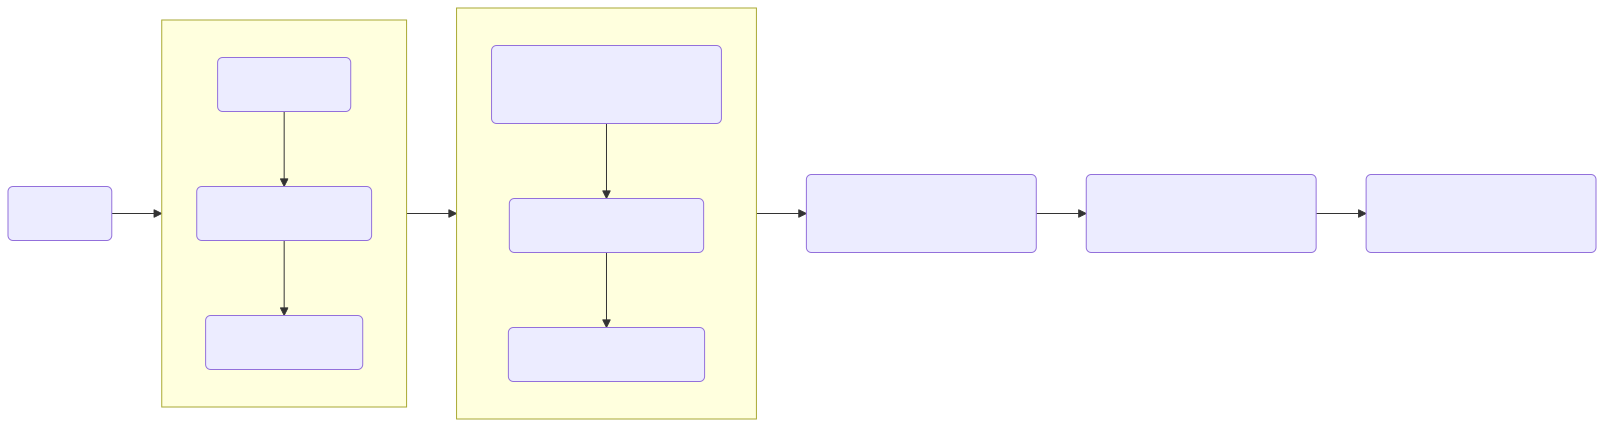

In [ ]:
advanced_rag_pipeline = """
graph LR 
    subgraph Data_Processing
        direction TB
        B(Data Ingestion) --> C(Data Transformation)
        C --> D(Data Embeddings)
    end 
  
    subgraph Chain
        direction TB 
        E(Create VectorDB from Embeddings) --> F(Defining the llm Model);
        F --> G(Define prompt template)
    end
     
    A(Input Data) --> Data_Processing
    Data_Processing --> Chain       

    Chain --> H(Create Retriever for VectorDB)
    H --> I(Create Retrieval Chain using 'Retriever' and 'Chain')
    I --> J(Get the response from given Query) 
  
"""

advanced_rag_pipeline_fn = "advanced_rag_pipeline.svg"
md.Mermaid(advanced_rag_pipeline).to_svg(advanced_rag_pipeline_fn)
SVG(advanced_rag_pipeline_fn)

#### A. Creating Prompt Template for Model

Let's design the prompt template to query the llm using that by adding fetched document as knowledge

In [33]:
# first we need the model to get the knowledge from
from langchain_ollama import OllamaLLM

llm = OllamaLLM(model="llama2")

In [31]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template("""

Answer the following question based only on the provided cotext. Think step by step before providing a detailed answer.
<context>
{context}
</context>                                          
Question: {input}""")

#### B. Creating Chain Instructions

In [34]:
from langchain.chains.combine_documents import create_stuff_documents_chain

# creating document chain for all the prompts, when we use with retriever, this will take all the retrieved documents and creates the prompts for us
documents_chain = create_stuff_documents_chain(llm, prompt)

In [35]:
documents_chain

RunnableBinding(bound=RunnableBinding(bound=RunnableAssign(mapper={
  context: RunnableLambda(format_docs)
}), kwargs={}, config={'run_name': 'format_inputs'}, config_factories=[])
| ChatPromptTemplate(input_variables=['context', 'input'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'input'], input_types={}, partial_variables={}, template='\n\nAnswer the following question based only on the provided cotext. Think step by step before providing a detailed answer.\n<context>\n{context}\n</context>                                          \nQuestion: {input}'), additional_kwargs={})])
| OllamaLLM(model='llama2')
| StrOutputParser(), kwargs={}, config={'run_name': 'stuff_documents_chain'}, config_factories=[])

#### C. Creating Retriever

In [38]:
retriever = db.as_retriever()

#### D. Creating Retriever - Chain

In [36]:
from langchain.chains import create_retrieval_chain

In [39]:
retrieval_chain = create_retrieval_chain(retriever, documents_chain)

Let's try getting output from this retriever chain using llama2 llm model

In [44]:
# creating the query
query3 = "What is BM25"

In [46]:
# invoking the retreival chain with the given query
result3 = retrieval_chain.invoke({"input":query3})

In [47]:
# let's see what we got here 
result3

{'input': 'What is BM25',
 'context': [Document(metadata={'total_pages': 18, 'source': 'd:\\ProjectDesk\\gh-iamatulkumar-ya\\data-science\\langchain_learning\\datafiles\\rag_study.pdf', 'creator': 'PyPDF', 'page_label': '6', 'title': 'A Comprehensive Review of Retrieval-Augmented Generation (RAG): Key Challenges and Future Directions', 'page': 5, 'creationdate': '', 'producer': 'Skia/PDF m131 Google Docs Renderer'}, page_content='2.2.1BM25'),
  Document(metadata={'creationdate': '', 'title': 'A Comprehensive Review of Retrieval-Augmented Generation (RAG): Key Challenges and Future Directions', 'total_pages': 18, 'producer': 'Skia/PDF m131 Google Docs Renderer', 'source': 'd:\\ProjectDesk\\gh-iamatulkumar-ya\\data-science\\langchain_learning\\datafiles\\rag_study.pdf', 'page': 5, 'page_label': '6', 'creator': 'PyPDF'}, page_content='BM25 is still widely used because of itssimplicityandefficiency. BM25iseffectivefor tasks involvingsimpler, keyword-basedqueries, althoughmoremodernretrieva

In [49]:
# let's get the answer

print("input query:", result3['input'])
print("llm answer:", result3['answer'])

input query: What is BM25
llm answer: Based on the provided context, BM25 appears to be a retrieval model that is widely used due to its simplicity and efficiency. It is effective for tasks involving simpler, keyword-based queries, but more modern retrieval models like DPR tend to outperform it in semantically complex tasks. BM25 is a term frequency-inverse document frequency (TF-IDF) weighted sum of the query terms in the document, where the weight is the logarithm of the total number of documents in the collection divided by the number of documents containing the term.

In the context provided, MemoRAG and NLLB-E5 are introduced as novel frameworks that aim to overcome the limitations of traditional RAG systems in handling ambiguous or unstructured knowledge. These models use a dual-system architecture, where a lightweight long-range language model (LLM) generates draft answers and guides retrieval tools, while a more powerful LLM refines the final output. The framework optimized for

Nice!!! So it is giving the answer, on the basis of the given text as a context. SO if the context is better then the llm output would also be better.

### Happy Learning!!!